<a href="https://colab.research.google.com/github/Sparshith-2001/drug-solubility-prediction/blob/main/drug_solubility_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [3]:
df.shape

(1128, 10)

In [4]:
df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   object 
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles                        

In [8]:
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


   ## Data overview
   - The dataset has 1,128 molecules and 10 columns.
   - There are no missing values.
   - Target: measured log solubility in mols per litre
   - The ESOL predicted column contains another model's predictions, so I will not use it as a feature.

In [12]:
df = df.rename(columns={
    "Compound ID": "name",
    "ESOL predicted log solubility in mols per litre": "esol_predicted",
    "Minimum Degree": "min_degree",
    "Molecular Weight": "mol_weight",
    "Number of H-Bond Donors": "hbd",
    "Number of Rings": "rings",
    "Number of Rotatable Bonds": "rot_bonds",
    "Polar Surface Area": "psa",
    "measured log solubility in mols per litre": "logS"
})

df.head()

,name,esol_predicted,min_degree,mol_weight,hbd,rings,rot_bonds,psa,logS,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [14]:
features = ["min_degree", "mol_weight", "hbd", "rings", "rot_bonds", "psa"]
target = "logS"

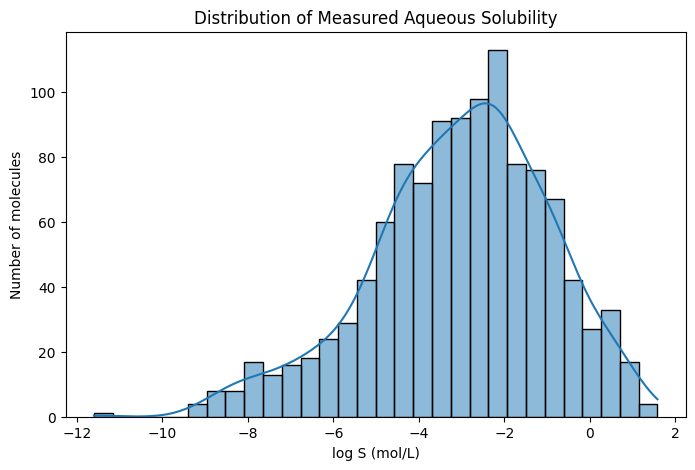

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, kde=True)
plt.xlabel("log S (mol/L)")
plt.ylabel("Number of molecules")
plt.title("Distribution of Measured Aqueous Solubility")
plt.show()

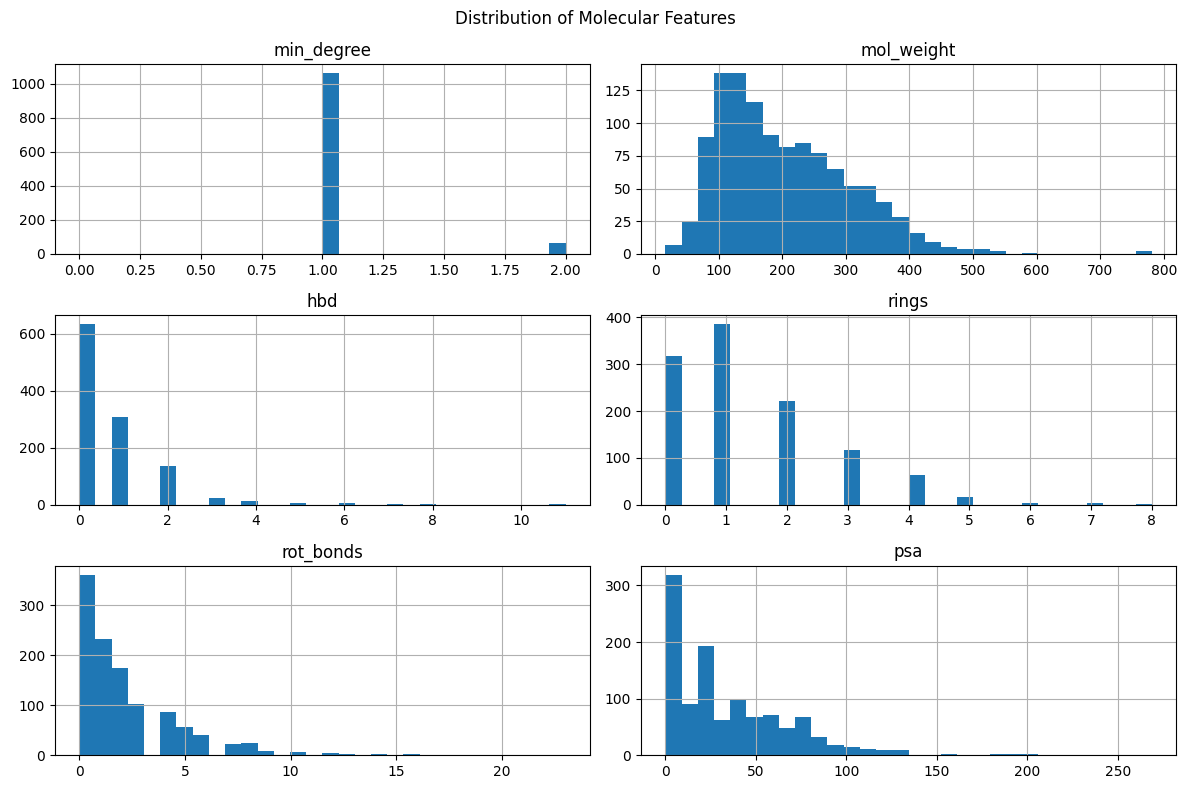

In [16]:
df[features].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Molecular Features")
plt.tight_layout()
plt.show()

## Distributions
- Most molecules have log S between -5 and 0 (peak around -2.5), with a tail of very insoluble compounds.
- Most molecules weigh 100–400 g/mol, have 0–2 H-bond donors and 0–4 rings.
- min_degree is almost always 1, so it may not be a useful feature.

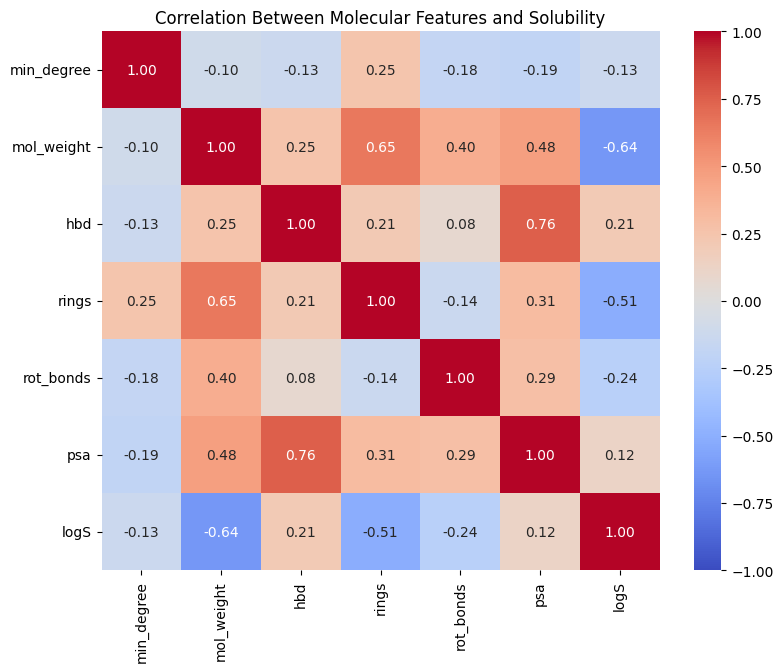

In [17]:
plt.figure(figsize=(9, 7))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Between Molecular Features and Solubility")
plt.show()

## Correlation analysis
- Molecular weight has the strongest relationship with solubility (r = -0.64): larger molecules are less soluble.
- Number of rings is also negatively correlated (r = -0.51), likely because aromatic rings are hydrophobic and pack tightly in crystals.
- H-bond donors (r = 0.21) and polar surface area (r = 0.12) have weak positive correlations.
- hbd and psa are strongly correlated with each other (r = 0.76), showing multicollinearity.
- logP, a key driver of solubility, is not in this dataset; adding it with RDKit is a possible improvement.

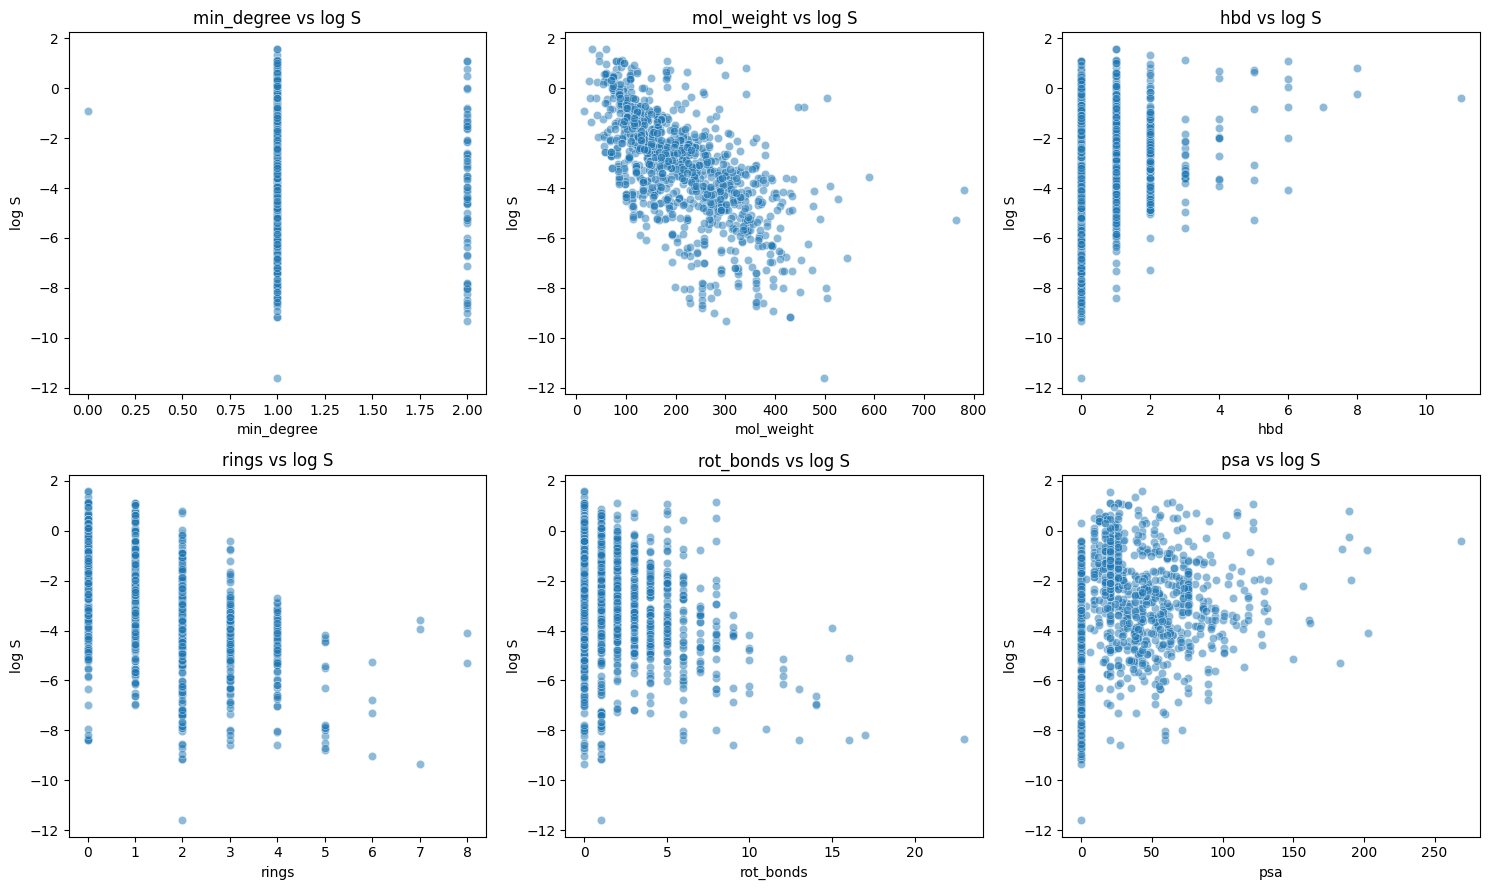

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(x=df[feature], y=df[target], ax=axes[i], alpha=0.5)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("log S")
    axes[i].set_title(f"{feature} vs log S")

plt.tight_layout()
plt.show()

## Scatter plots
- Molecular weight shows a clear negative trend with log S, but with a wide spread, so no single feature is enough to predict solubility.
- Solubility tends to decrease as the number of rings increases.
- Molecules with zero polar surface area cover almost the whole solubility range.

In [19]:
X = df[features]
y = df[target]

print(X.shape, y.shape)

(1128, 6) (1128,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training molecules:", len(X_train))
print("Test molecules:", len(X_test))

Training molecules: 902
Test molecules: 226


In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred_lr = lr.predict(X_test)

r2 = r2_score(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression R²:   {r2:.3f}")
print(f"Linear Regression RMSE: {rmse:.3f}")
print(f"Linear Regression MAE:  {mae:.3f}")

Linear Regression R²:   0.696
Linear Regression RMSE: 1.199
Linear Regression MAE:  0.892


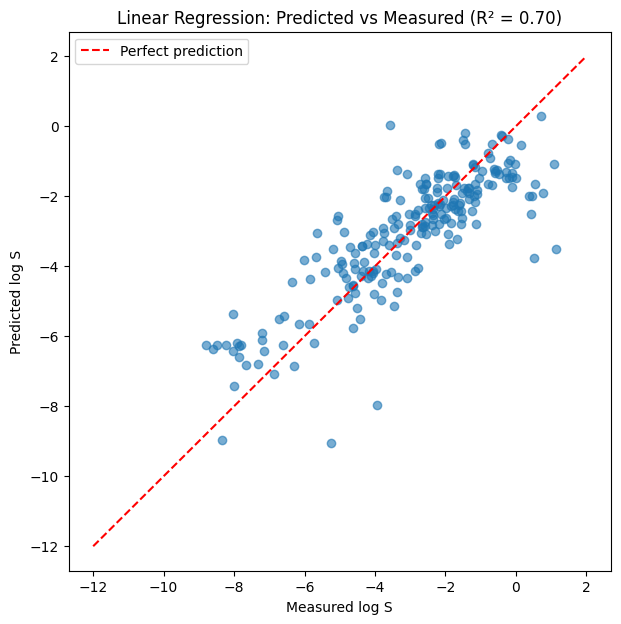

In [23]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([-12, 2], [-12, 2], "r--", label="Perfect prediction")
plt.xlabel("Measured log S")
plt.ylabel("Predicted log S")
plt.title(f"Linear Regression: Predicted vs Measured (R² = {r2:.2f})")
plt.legend()
plt.show()

In [24]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": lr.coef_
}).sort_values("coefficient")

coef_table

,feature,coefficient
3,rings,-0.406753
0,min_degree,-0.275106
4,rot_bonds,-0.151342
1,mol_weight,-0.013441
5,psa,0.031018
2,hbd,0.108265


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [26]:
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest R²:   {r2_rf:.3f}")
print(f"Random Forest RMSE: {rmse_rf:.3f}")
print(f"Random Forest MAE:  {mae_rf:.3f}")

Random Forest R²:   0.826
Random Forest RMSE: 0.908
Random Forest MAE:  0.604


In [27]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R²": [r2, r2_rf],
    "RMSE": [rmse, rmse_rf],
    "MAE": [mae, mae_rf]
}).round(3)

results

,Model,R²,RMSE,MAE
0,Linear Regression,0.696,1.199,0.892
1,Random Forest,0.826,0.908,0.604


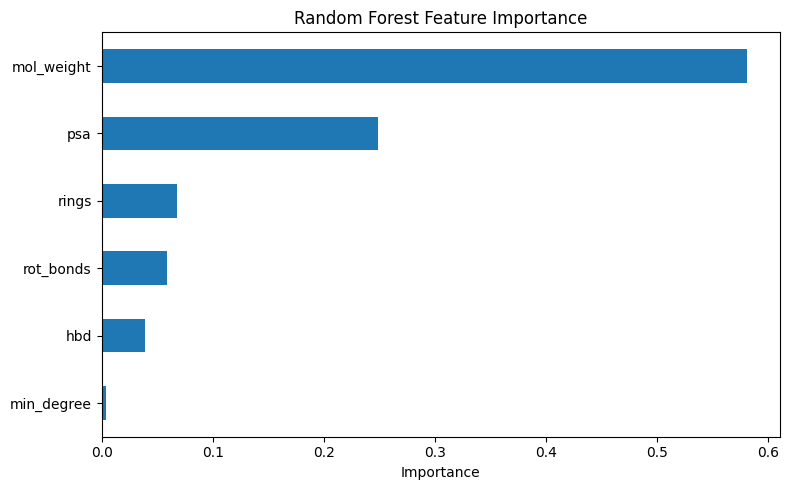

In [28]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Random forest results
- Random forest outperformed linear regression: R² 0.826 vs 0.696, MAE 0.604 vs 0.892 (about 32% lower error).
- Molecular weight was the most important feature, matching the correlation analysis.
- Polar surface area was the second most important feature despite a weak linear correlation (r = 0.12), suggesting its effect depends on molecular size, a non-linear interaction that linear regression cannot capture.
- Rings had low importance because their information overlaps with molecular weight.
- min_degree contributed almost nothing.

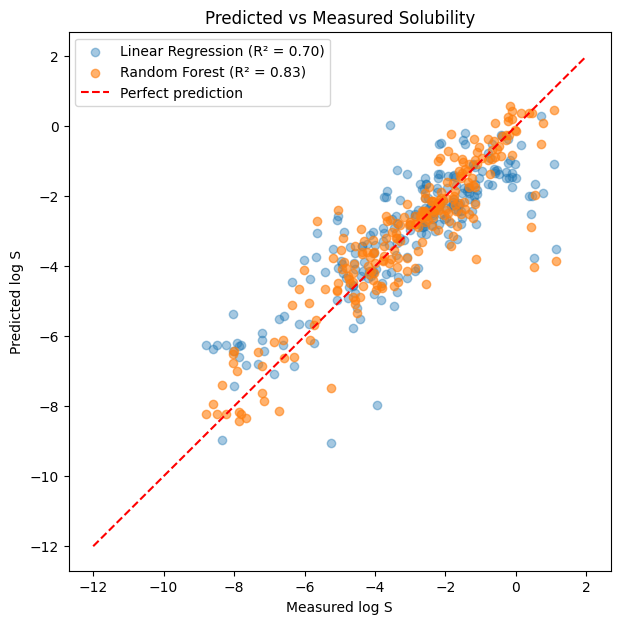

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lr, alpha=0.4, label=f"Linear Regression (R² = {r2:.2f})")
plt.scatter(y_test, y_pred_rf, alpha=0.6, label=f"Random Forest (R² = {r2_rf:.2f})")
plt.plot([-12, 2], [-12, 2], "r--", label="Perfect prediction")
plt.xlabel("Measured log S")
plt.ylabel("Predicted log S")
plt.title("Predicted vs Measured Solubility")
plt.legend()
plt.show()

## Conclusion
- A random forest model predicted aqueous solubility with R² = 0.83 and MAE = 0.60 log units, outperforming a linear regression baseline (R² = 0.70, MAE = 0.89).
- The random forest greatly improved predictions for very insoluble compounds, which linear regression overestimated.
- Molecular weight and polar surface area were the most important features. PSA mattered far more than its linear correlation suggested, showing a non-linear interaction with molecular size.

## Limitations and future work
- Only 6 simple descriptors were used. Adding logP and other descriptors calculated with RDKit from the SMILES strings should improve accuracy.
- A few highly soluble compounds were still underpredicted by both models.
- Results come from a single train/test split; cross-validation would give a more reliable estimate.
- Permutation importance would give a more reliable ranking of features.